In [1]:
import numpy as np
from numpy import degrees
from math import radians, tan, sqrt, atan
from scipy.stats import t
from scipy.optimize import fsolve


# 1) ORIGINAL BISHOP METHOD


def get_alpha_r(x, z, H, xB):
    MFl = np.array([-x,-z])
    FBl = np.array([xB(x,z), H])
    MBl = FBl + MFl
    return np.arccos(np.dot(MFl, MBl)/(np.linalg.norm(MFl)*np.linalg.norm(MBl))) / 2

def is_valid_circle(x,z,beta,H,xB):
    return (xB(x,z) >= H/np.tan(beta))

def run_analysis(phi, c, beta, H, gamma):
    # phi is in radians here
    Radius = lambda x, z: np.sqrt(x**2 + z**2)
    xB = lambda x, z: x + np.sqrt(Radius(x,z)**2 - (z-H)**2)

    Mx = np.linspace(-H, H/np.tan(beta), 30)
    Mz = np.linspace(0.8 * H, 4 * H, 20)

    etas = np.zeros((len(Mz), len(Mx)))
    eta_min = 9999
    x_max = z_max = L_max = 0.0

    for j, x in enumerate(Mx):
        for i, z in enumerate(Mz):

            if not is_valid_circle(x, z, beta, H, xB):
                etas[i,j] = None
                continue

            r = Radius(x, z)
            MF = np.array([-x,-z])
            FB = np.array([xB(x,z),H])
            MB = FB + MF

            FS = np.array([H/np.tan(beta), H])
            MS = FS + MF

            MP = lambda psi: np.array([r*np.sin(psi), -r*np.cos(psi)])
            SP = lambda psi: MP(psi) - MS
            MC = lambda psi: MS + (2./3.)*(SP(psi))

            alpha_r = get_alpha_r(x, z, H, xB)

            alpha_0 = np.arctan(-x/z)
            alpha_1 = alpha_0 + 2*alpha_r
            alphas = np.linspace(alpha_0, alpha_1, 50)

            A = 0; eA = 0
            for k in range(1, len(alphas)):
                r0 = np.linalg.norm(SP(alphas[k-1]))
                r1 = np.linalg.norm(SP(alphas[k]))
                dpsi = np.arccos(np.dot(SP(alphas[k-1]), SP(alphas[k])) /
                                 (np.linalg.norm(SP(alphas[k-1])) * np.linalg.norm(SP(alphas[k]))))
                dA = (r0+r1)**2 * dpsi / 8
                A += dA
                eA += dA * MC(0.5*(alphas[k]+alphas[k-1]))[0]

            e = eA / A
            F = gamma * A
            MT = F * e

            l_FB = np.linalg.norm(FB)
            rc = alpha_r/np.sin(alpha_r) * r
            beta_F = np.arctan(FB[1]/FB[0])
            Fc_vec = np.array([c*l_FB*np.cos(beta_F), c*l_FB*np.sin(beta_F)])
            MFc = c * l_FB * rc

            Q = -np.array([0,-F]) - Fc_vec
            xi = (1 + alpha_r/np.sin(alpha_r)) / 2

            # Initial guess
            mu_0 = MT / (MFc + np.linalg.norm(Q) * xi * r * np.sin(phi))

            f_test = lambda mu_i: ( MT /
                (MFc*mu_i + np.linalg.norm(-np.array([0,-F]) - mu_i*Fc_vec) * xi * r *
                 np.sin(np.arctan(mu_i*np.tan(phi))) ) ) - 1

            mu_1 = fsolve(f_test, mu_0)[0]
            eta = 1/mu_1
            etas[i,j] = eta

            if eta < eta_min:
                eta_min = eta
                x_max = x
                z_max = z
                L_max = r * 2 * alpha_r

    return eta_min, L_max, x_max, z_max



# 2) CHARACTERISTIC VALUE & Γ² UTILITIES 


def kn_from_gamma_sq(gamma_sq, Case, n):
    gamma_sq = float(np.clip(gamma_sq, 0, 1))
    N95 = 1.645
    t95 = t.ppf(0.95, n-1)

    if Case in ("1","3"):
        return N95 * np.sqrt(gamma_sq + 1/n)
    else:
        return t95 * np.sqrt(gamma_sq + 1/n)

def char_value(mean, cov, gamma_sq, Case, n):
    k_n = kn_from_gamma_sq(gamma_sq, Case, n)
    return mean * (1 - k_n * cov)

def implied_gamma_sq(theta, L):
    if L <= 0 or not np.isfinite(L):
        return 1.0
    return float(min(1.0, max(0.0, theta/L)))



# 3) THE Γ²–ϕ BISECTION SOLVER FOR SLOPE STABILITY


def solve_gamma_phi_slope(
    *, phi_mean, phi_cov, phi_theta,
    c_mean, c_cov, c_theta,
    Case, n,
    beta, H, gamma,
    tol=1e-4, itmax=60,
    g_init=None
):
    """
    Solve g² = implied_gamma_sq(theta / L(phi_k(g²))) for slope stability
    using bisection if possible, else relaxed fixed-point.

    Fully aligned with foundation version:
    - Always return: gamma_sq, g2_residual, method, iterations, phi_k,
      c_k, L, eta_k.
    """

    # -------------------------------------------------------
    # residual evaluation at a given g2
    # -------------------------------------------------------
    def eval_at(g2):

        # --- Characteristic values ---
        phi_k = char_value(phi_mean, phi_cov, g2, Case, n)
        c_k   = char_value(c_mean,  c_cov,  g2, Case, n) if c_cov > 0 else c_mean

        phi_rad = radians(phi_k)

        # --- Compute slip circle length L(φ_k, c_k) ---
        eta_k, L_arc, xM, zM = run_analysis(phi_rad, c_k, beta, H, gamma)

        # --- Implied gamma² from characteristic length ---
        g2_real = implied_gamma_sq(phi_theta, L_arc)

        # --- Return full diagnostics ---
        return {
            "res"      : g2 - g2_real,
            "g2_real"  : g2_real,
            "phi_k"    : phi_k,
            "c_k"      : c_k,
            "L"        : L_arc,
            "eta_k"    : eta_k,
        }

    # -------------------------------------------------------
    # Try bisection on [0,1]
    # -------------------------------------------------------
    lo, hi = 0.0, 1.0
    e_lo, e_hi = eval_at(lo), eval_at(hi)

    bracket_ok = (
        np.isfinite(e_lo["res"])
        and np.isfinite(e_hi["res"])
        and e_lo["res"] * e_hi["res"] <= 0.0
    )

    if bracket_ok:
        a_g, b_g = lo, hi
        a_e, b_e = e_lo, e_hi

        for it in range(1, itmax + 1):
            mid = 0.5 * (a_g + b_g)
            e_m = eval_at(mid)

            # Converged
            if abs(e_m["res"]) < tol:
                return {
                    "gamma_sq"   : mid,
                    "g2_residual": abs(e_m["res"]),
                    "method"     : "bisection",
                    "iterations" : it,
                    **{k: e_m[k] for k in e_m if k != "res"},
                }

            # keep left or right interval
            if a_e["res"] * e_m["res"] <= 0.0:
                b_g, b_e = mid, e_m
            else:
                a_g, a_e = mid, e_m

        # Max iterations: return midpoint result
        mid = 0.5 * (a_g + b_g)
        e_m = eval_at(mid)
        return {
            "gamma_sq"   : mid,
            "g2_residual": abs(e_m["res"]),
            "method"     : "bisection",
            "iterations" : itmax,
            **{k: e_m[k] for k in e_m if k != "res"},
            "note"       : "g2 bisection max-iter",
        }

    # -------------------------------------------------------
    # fallback: relaxed fixed-point iteration
    # -------------------------------------------------------
    g = float(np.clip(0.5 if g_init is None else g_init, 0.0, 1.0))   # initialize g, clip it between 0 and 1

    for it in range(1, itmax + 1):
        e = eval_at(g)
        g_new = 0.5 * g + 0.5 * e["g2_real"]

        # Convergence
        if abs(g_new - g) < tol:
            e_done = eval_at(g_new)
            return {
                "gamma_sq"   : g_new,
                "g2_residual": abs(e_done["res"]),
                "method"     : "fixed-point",
                "iterations" : it,
                **{k: e_done[k] for k in e_done if k != "res"},
            }

        g = float(np.clip(g_new, 0, 1))

    # Max iterations: return last iteration
    e = eval_at(g)
    return {
        "gamma_sq"   : g,
        "g2_residual": abs(e["res"]),
        "method"     : "fixed-point",
        "iterations" : itmax,
        **{k: e[k] for k in e if k != "res"},
        "note"       : "fixed-point max-iter",
    }




# 4) EXAMPLE: RUN SLOPE Γ²–ϕ CONSISTENCY


if __name__ == "__main__":

    # Slope geometry
    H = 12
    beta_deg = 28
    beta = radians(beta_deg)

    # Soil means
    phi_mean = 30
    c_mean = 2
    gamma = 18

    # Characteristic parameters
    phi_cov = 0.10
    c_cov = 0.40
    phi_theta = 5   # try small or large
    c_theta = 5
    Case = "2"
    n = 30

    sol = solve_gamma_phi_slope(
        phi_mean=phi_mean,
        phi_cov=phi_cov,
        phi_theta=phi_theta,
        c_mean=c_mean,
        c_cov=c_cov,
        c_theta=c_theta,
        Case=Case, n=n,
        beta=beta, H=H, gamma=gamma,
        tol=1e-4, itmax=40
    )

    print("\n================= SLOPE Γ²–ϕ SOLUTION =================")
    print(f"Gamma^2*: {sol['gamma_sq']:.5f}   ({sol['method']}, {sol['iterations']} iters)")
    print(f"phi_k*:   {sol['phi_k']:.4f} deg")
    print(f"c_k*:     {sol['c_k']:.4f}")
    print(f"L*:       {sol['L']:.4f} m")
    print(f"eta_k*:   {sol['eta_k']:.4f}  (FS ≥ 1 → safe)")
    print("=========================================================\n")



================= SLOPE Γ²–ϕ SOLUTION =================
Gamma^2*: 0.18958   (bisection, 13 iters)
phi_k*:   27.5934 deg
c_k*:     1.3582
L*:       26.3743 m
eta_k*:   1.1477  (FS ≥ 1 → safe)



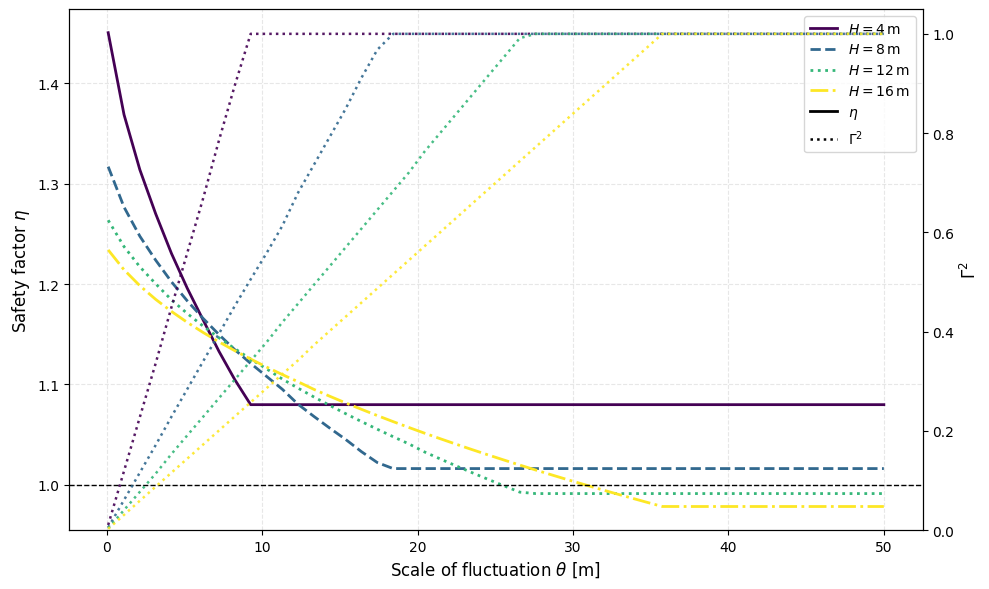

In [2]:
import itertools
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# PARAMETRIC CONFIGURATION

theta_values = np.linspace(0.1, 50.0, 50)   # scale of fluctuation [m]
H_values = [4, 8, 12, 16]                   # slope heights [m]

# soil parameters
phi_mean  = 30
phi_cov   = 0.10
phi_theta = 5

c_mean  = 2
c_cov   = 0.40
c_theta = 5

gamma = 22
beta_deg = 27
beta = radians(beta_deg)

Case = "2"
n = 30


# PLOTTING: η vs θ (left) + Γ² (right)


fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

cmap = plt.cm.viridis
colors = [cmap(i/max(len(H_values)-1, 1)) for i in range(len(H_values))]
ls_cycle = itertools.cycle(["-", "--", ":", "-."])

# ----------------------------------------------------------
# LOOP OVER H
# ----------------------------------------------------------
results = {}
for color, H in zip(colors, H_values):

    ls = next(ls_cycle)
    eta_vals = []
    gamma_vals = []

    for theta in theta_values:
        sol = solve_gamma_phi_slope(
            phi_mean=phi_mean, phi_cov=phi_cov, phi_theta=float(theta),
            c_mean=c_mean, c_cov=c_cov, c_theta=c_theta,
            Case=Case, n=n,
            beta=beta, H=H, gamma=gamma
        )

        eta_vals.append(sol["eta_k"])
        gamma_vals.append(sol["gamma_sq"])

    eta_vals = np.array(eta_vals)
    gamma_vals = np.array(gamma_vals)

    # --- Store results for second plot ---
    results[H] = {
        "theta": np.array(theta_values),
        "eta": eta_vals,
        "gamma_sq": gamma_vals
    }

    # η curves (left axis)
    ax1.plot(
        theta_values, eta_vals,
        color=color, linestyle=ls, linewidth=2,
        label=rf"$H = {H}\,\mathrm{{m}}$"
    )

    # Γ² curves (right axis)
    ax2.plot(
        theta_values, gamma_vals,
        color=color, linestyle=":", linewidth=1.8,
        alpha=0.9, label="_nolegend_"
    )

# ==========================================================
# Formatting
# ==========================================================

# Safety threshold η = 1
ax1.axhline(y=1.0, color="k", linestyle="--", linewidth=1)

ax1.set_xlabel(r"Scale of fluctuation $\theta$ [m]", fontsize=12)
ax1.set_ylabel(r"Safety factor $\eta$", fontsize=12)
ax2.set_ylabel(r"$\Gamma^2$", fontsize=12)

ax1.grid(True, linestyle="--", alpha=0.3)
ax2.set_ylim(0, 1.05)

# Legend
h, l = ax1.get_legend_handles_labels()
style_handles = [
    Line2D([0], [0], color="k", linestyle="-", linewidth=2, label=r"$\eta$"),
    Line2D([0], [0], color="k", linestyle=":", linewidth=1.8, label=r"$\Gamma^2$")
]

ax1.legend(h + style_handles, l + [r"$\eta$", r"$\Gamma^2$"], loc="best")

fig.tight_layout()
plt.show()


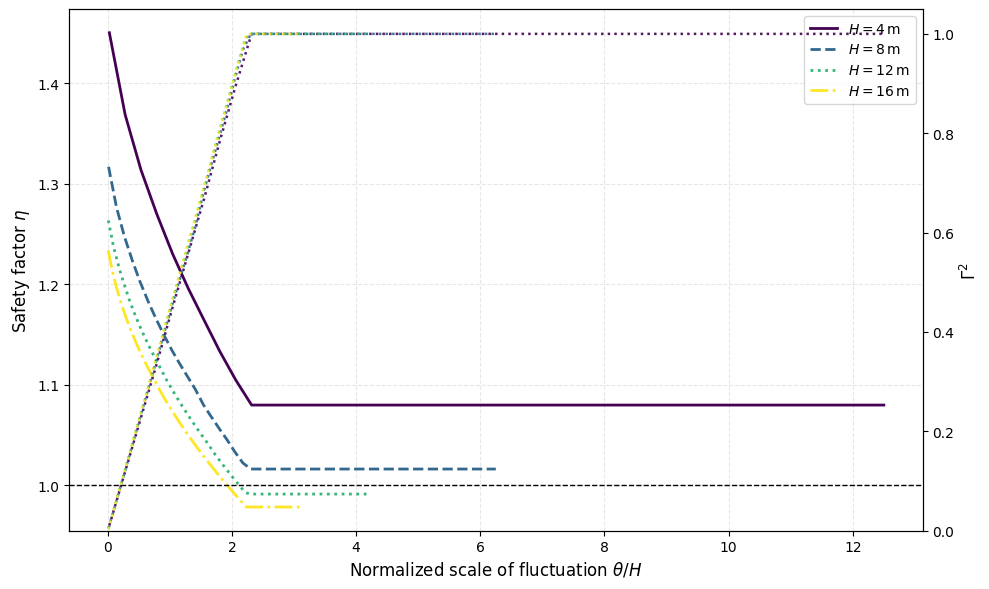

In [3]:
# ==========================================================
# SECOND PLOT — using stored results (NO recomputation)
# ==========================================================

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

cmap = plt.cm.viridis
colors = [cmap(i/max(len(H_values)-1, 1)) for i in range(len(H_values))]
ls_cycle = itertools.cycle(["-", "--", ":", "-."])

for color, H in zip(colors, H_values):

    ls = next(ls_cycle)

    theta_norm = results[H]["theta"] / H     # θ/H
    eta_vals   = results[H]["eta"]
    gamma_vals = results[H]["gamma_sq"]

    # η curves
    ax1.plot(
        theta_norm, eta_vals,
        color=color, linestyle=ls, linewidth=2,
        label=rf"$H = {H}\,\mathrm{{m}}$"
    )

    # Γ² curves
    ax2.plot(
        theta_norm, gamma_vals,
        color=color, linestyle=":", linewidth=1.8,
        alpha=0.9, label="_nolegend_"
    )

# formatting
ax1.axhline(y=1.0, color="k", linestyle="--", linewidth=1)
ax1.set_xlabel(r"Normalized scale of fluctuation $\theta/H$", fontsize=12)
ax1.set_ylabel(r"Safety factor $\eta$", fontsize=12)
ax2.set_ylabel(r"$\Gamma^2$", fontsize=12)
ax1.grid(True, linestyle="--", alpha=0.3)
ax2.set_ylim(0,1.05)

# legend
h, l = ax1.get_legend_handles_labels()
ax1.legend(h, l, loc="best")

plt.tight_layout()
plt.show()


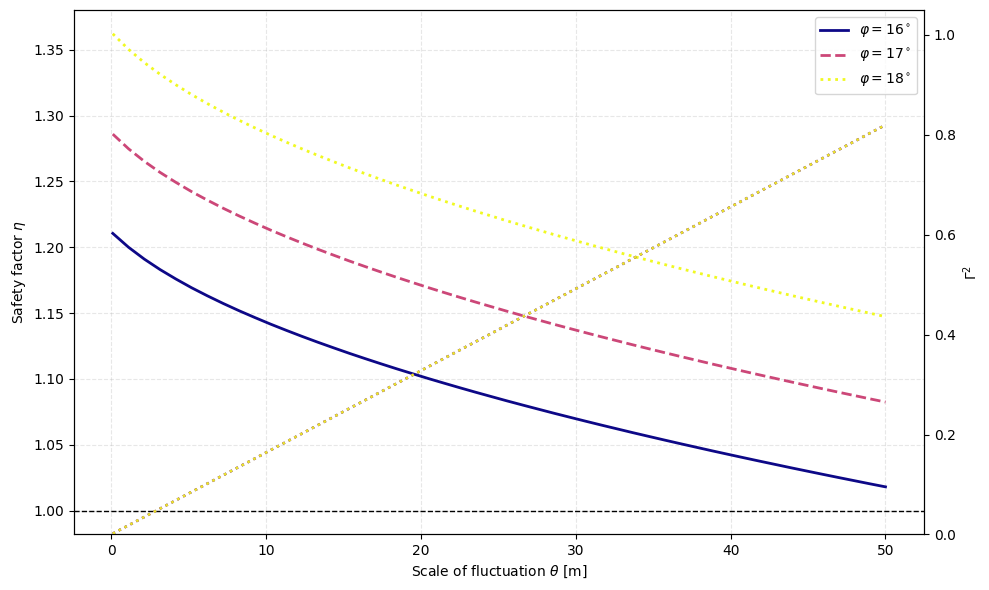

In [6]:
# ==========================================================
# PLOT 1 — Different friction angles φ_mean vs theta
# ==========================================================

phi_list = [31, 32, 33]      # degrees
H_fixed = 15                         # keep slope height fixed
beta_deg = 30                       # fixed slope angle < ALL φ_mean
beta = radians(beta_deg)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

cmap = plt.cm.plasma
colors = [cmap(i/max(len(phi_list)-1,1)) for i in range(len(phi_list))]
ls_cycle = itertools.cycle(["-", "--", ":", "-."])

for color, phi_mean_var in zip(colors, phi_list):

    ls = next(ls_cycle)
    eta_vals = []
    gamma_vals = []

    for theta in theta_values:
        sol = solve_gamma_phi_slope(
            phi_mean=phi_mean_var,
            phi_cov=phi_cov,
            phi_theta=float(theta),
            c_mean=c_mean,
            c_cov=c_cov,
            c_theta=c_theta,
            Case=Case, n=n,
            beta=beta,
            H=H_fixed,
            gamma=gamma
        )
        eta_vals.append(sol["eta_k"])
        gamma_vals.append(sol["gamma_sq"])

    ax1.plot(theta_values, eta_vals, color=color, linestyle=ls, linewidth=2,
             label=rf"$\varphi = {phi_mean_var}^\circ$")
    ax2.plot(theta_values, gamma_vals, color=color, linestyle=":", linewidth=1.8,
             alpha=0.9, label="_nolegend_")

ax1.axhline(y=1.0, color="k", linestyle="--", linewidth=1)
ax1.set_xlabel(r"Scale of fluctuation $\theta$ [m]")
ax1.set_ylabel(r"Safety factor $\eta$")
ax2.set_ylabel(r"$\Gamma^2$")
ax1.grid(True, linestyle="--", alpha=0.3)
ax2.set_ylim(0,1.05)
ax1.legend(loc="best")
plt.tight_layout()
plt.show()


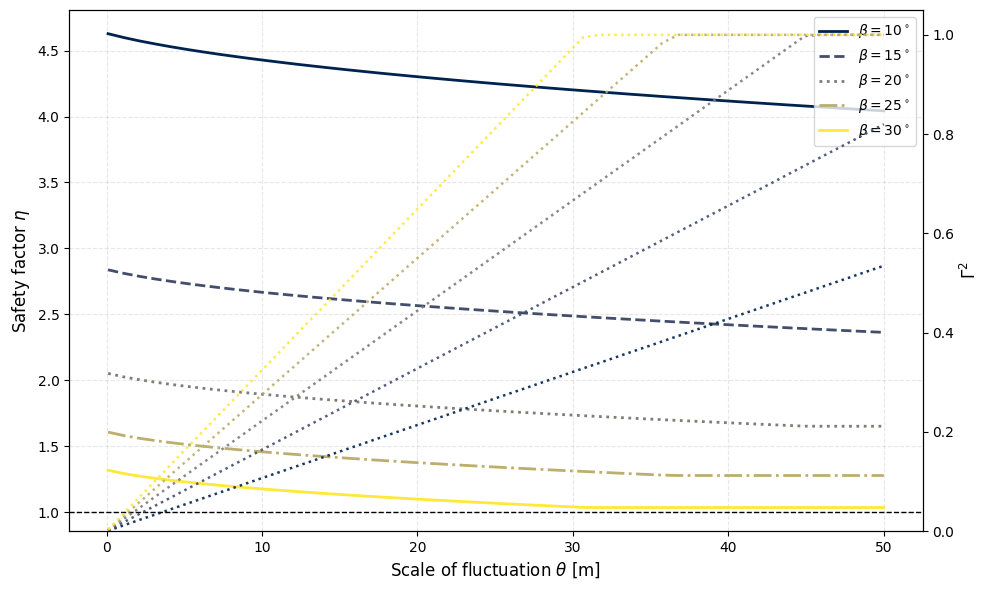

In [ ]:
# ==========================================================
# PLOT — Different slope inclinations β vs θ, with fixed φ_mean
# ==========================================================

phi_mean_fixed = 35        # same friction angle for ALL cases
beta_list = [30,32,34]   # candidate slope angles (deg)

H_fixed = 15

# Filter slope angles so that β < φ_mean (always safe)
beta_valid = [b for b in beta_list if b < phi_mean_fixed]

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

cmap = plt.cm.cividis
colors = [cmap(i / max(len(beta_valid)-1, 1)) for i in range(len(beta_valid))]
ls_cycle = itertools.cycle(["-", "--", ":", "-."])

for color, beta_deg in zip(colors, beta_valid):

    beta = radians(beta_deg)
    ls = next(ls_cycle)

    eta_vals = []
    gamma_vals = []

    for theta in theta_values:
        sol = solve_gamma_phi_slope(
            phi_mean=phi_mean_fixed,
            phi_cov=phi_cov,
            phi_theta=float(theta),
            c_mean=c_mean,
            c_cov=c_cov,
            c_theta=c_theta,
            Case=Case, n=n,
            beta=beta,
            H=H_fixed,
            gamma=gamma
        )
        eta_vals.append(sol["eta_k"])
        gamma_vals.append(sol["gamma_sq"])

    # Plot η(θ) on left axis
    ax1.plot(theta_values, eta_vals,
             color=color, linestyle=ls, linewidth=2,
             label=rf"$\beta = {beta_deg}^\circ$")

    # Plot Γ²(θ) on right axis
    ax2.plot(theta_values, gamma_vals,
             color=color, linestyle=":", linewidth=1.8,
             alpha=0.9, label="_nolegend_")

# Formatting
ax1.axhline(1.0, color="k", linestyle="--", linewidth=1)
ax1.set_xlabel(r"Scale of fluctuation $\theta$ [m]", fontsize=12)
ax1.set_ylabel(r"Safety factor $\eta$", fontsize=12)
ax2.set_ylabel(r"$\Gamma^2$", fontsize=12)

ax1.grid(True, linestyle="--", alpha=0.3)
ax2.set_ylim(0, 1.05)

ax1.legend(loc="best")
plt.tight_layout()
plt.show()
